In [2]:
pip install cvxpy

  Using cached osqp-1.1.1-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.2 kB)
  Using cached clarabel-0.11.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.8 kB)
  Using cached scs-3.2.11-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (2.8 kB)
  Using cached highspy-1.13.1-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 13.3 MB/s  0:00:00
Using cached clarabel-0.11.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.2 MB)
Using cached highspy-1.13.1-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (2.5 MB)
Using cached osqp-1.1.1-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (345 kB)
Using cached scs-3.2.11-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (12.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [cvxpy]32m4/5 [cvxpy]
Note: you may need to restart the kernel to use updated 

In [11]:
pip install ecos 

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ecos: filename=ecos-2.0.14-cp313-cp313-linux_x86_64.whl size=83058 sha256=b48e61ecaf3c7d01bd815a72496dddc0230746b19d7ea237a29d95517db07964
  Stored in directory: /home/jupyter/.cache/pip/wheels/6b/82/0b/4bb5aa6c4618f367601a45db8710205d56858808423974e92a
Successfully built ecos
Note: you may need to restart the kernel to use updated packages.


In [13]:
import cvxpy as cp
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [37]:
def process_image(image_path, target_size=(100, 100),lam1=0.1, lam2=0.01):
    # 1. Load and Resize (Crucial for solver speed!)
    img = Image.open(image_path).convert('L') # Convert to Grayscale
    img = img.resize(target_size)
    f_original = np.array(img, dtype=np.float64)
    
    # 2. Simulate "Old Photo" (Add blur and noise)
    # In a real project, this 'f' would be your actual old photo.
    f_blur = f_original + np.random.normal(0, 10, f_original.shape) 
    f_blur = np.clip(f_blur, 0, 255)

    # 3. Define Optimization Variables
    m, n = f_blur.shape
    u = cp.Variable((m, n))

    # 4. Define the Objective (Matching your equation)
    # Term 1: Data Fidelity ||u - f||^2
    fidelity = cp.sum_squares(u - f_blur)
    
    # Term 2: Sparsity (Total Variation) - lambda1 * ||grad u||_1
    # This is the "secret sauce" for high-res edges
    lam1 = 0.1 
    tv_penalty = lam1 * cp.tv(u)

    # 3. Smoothness Term: lambda2 * ||grad u||_2^2
    # We approximate the L2 gradient norm using differences
    diff_h = u[:, 1:] - u[:, :-1]
    diff_v = u[1:, :] - u[:-1, :]
    smoothness = lam2 * (cp.sum_squares(diff_h) + cp.sum_squares(diff_v))
    
    objective = cp.Minimize(fidelity + tv_penalty + smoothness)

    # 5. Constraints: 0 <= u <= 500
    constraints = [u >= 0, u <= 500]

    # 6. Solve using SCS (more common than ECOS)
    print("Solving... this may take a minute for larger images.")
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS, verbose=True)

    return f_blur, u.value

(CVXPY) Mar 30 06:50:52 PM: Your problem has 10000 variables, 20000 constraints, and 0 parameters.
(CVXPY) Mar 30 06:50:52 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 30 06:50:52 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 30 06:50:52 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 30 06:50:52 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 30 06:50:52 PM: Compiling problem (target solver=SCS).
(CVXPY) Mar 30 06:50:52 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Mar 30 06:50:52 PM: Applying reduction Dcp2Cone
(CVXPY) Mar 30 06:50:52 PM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 30 06:50:52 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 30 06:50:52 PM: Applying reduction SCS
(CVXPY) Mar 30 06:50:52 PM: Finished problem compilation (took

Solving... this may take a minute for larger images.
                                     CVXPY                                     
                                     v1.8.2                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 49601, constraints m: 79203
cones: 	  z: primal zero /

(CVXPY) Mar 30 06:50:53 PM: Problem status: optimal
(CVXPY) Mar 30 06:50:53 PM: Optimal value: 1.202e+05
(CVXPY) Mar 30 06:50:53 PM: Compilation took 1.142e-01 seconds
(CVXPY) Mar 30 06:50:53 PM: Solver (including time spent in interface) took 5.153e-01 seconds


    75| 2.44e-03  6.57e-05  1.92e-02  1.20e+05  1.00e-01  5.07e-01 
------------------------------------------------------------------
status:  solved
timings: total: 5.08e-01s = setup: 1.49e-01s + solve: 3.59e-01s
	 lin-sys: 2.04e-01s, cones: 5.94e-02s, accel: 1.91e-02s
------------------------------------------------------------------
objective = 120235.849070
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


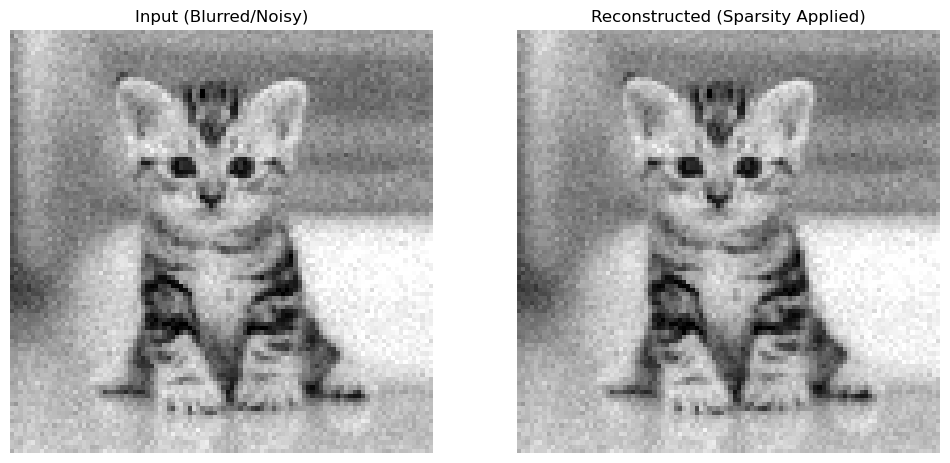

In [38]:
# --- EXECUTION ---
try:
    blurred, reconstructed = process_image('kitten.jpg', target_size=(100, 100))

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Input (Blurred/Noisy)")
    plt.imshow(blurred, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Reconstructed (Sparsity Applied)")
    plt.imshow(reconstructed, cmap='gray')
    plt.axis('off')

    plt.show()
except FileNotFoundError:
    print("Error: Please make sure 'your_photo.jpg' is in the same folder as this script.")